In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator   
import tensorflow as tf  

In [38]:
train_path = "/mnt/d/Medical-Image-Diagnosis/data/bone_fracture/train"
validation_path = "/mnt/d/Medical-Image-Diagnosis/data/bone_fracture/val"
test_path = "/mnt/d/Medical-Image-Diagnosis/data/bone_fracture/test"

In [39]:
for path in [train_path, validation_path, test_path]:
    print("\n", path)

    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):
            print(class_name, ":", len(os.listdir(class_path)))


 /mnt/d/Medical-Image-Diagnosis/data/bone_fracture/train
fractured : 4606
not fractured : 4634

 /mnt/d/Medical-Image-Diagnosis/data/bone_fracture/val
fractured : 337
not fractured : 486

 /mnt/d/Medical-Image-Diagnosis/data/bone_fracture/test
fractured : 238
not fractured : 262


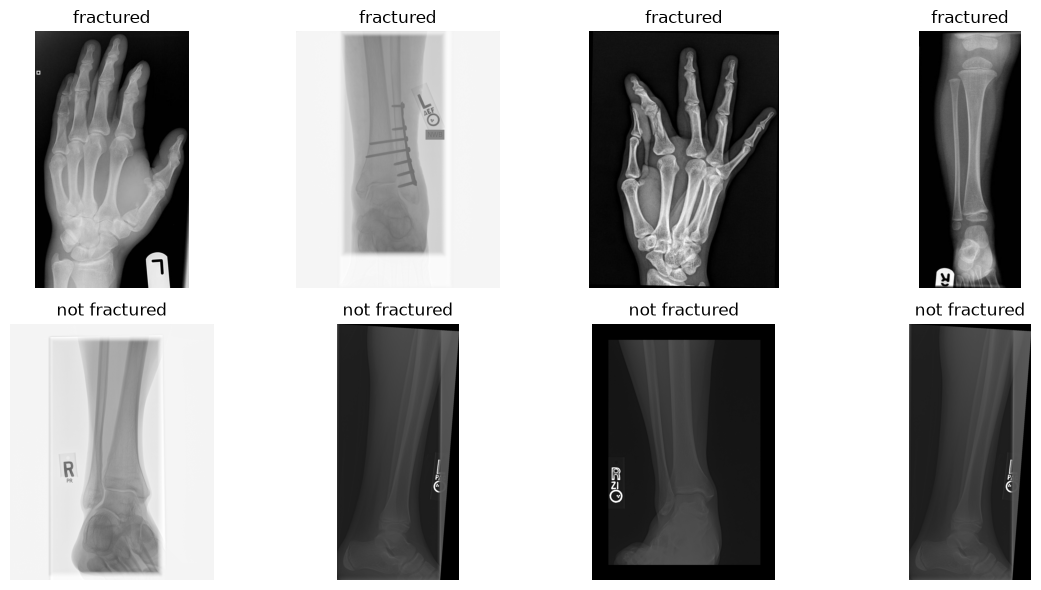

In [40]:
from tensorflow.keras.utils import load_img

classes = ["fractured", "not fractured"]

plt.figure(figsize=(12, 6))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    for i in range(4):
        image_name = os.listdir(class_path)[i]
        image_path = os.path.join(class_path, image_name)

        img = load_img(image_path)

        plt.subplot(2, 4, plot_index)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [41]:
print("Train classes:",os.listdir(train_path))
print("Validation classes:", os.listdir(validation_path))
print("Test classes:", os.listdir(test_path))

Train classes: ['fractured', 'not fractured']
Validation classes: ['fractured', 'not fractured']
Test classes: ['fractured', 'not fractured']


In [42]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

Found 9240 images belonging to 2 classes.


In [43]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_set = validation_datagen.flow_from_directory(
    validation_path,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 823 images belonging to 2 classes.


In [44]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 500 images belonging to 2 classes.


In [45]:
print("Training images:", training_set.samples)
print("Validation images:", validation_set.samples)
print("Test images:", test_set.samples)

print("Class indices:", training_set.class_indices)

Training images: 9240
Validation images: 823
Test images: 500
Class indices: {'fractured': 0, 'not fractured': 1}


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout
model = Sequential()


BLOCK of cnn


In [47]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    BatchNormalization, Dropout,
    GlobalAveragePooling2D, Dense
)
model = Sequential([
    
    Input(shape=(224, 224, 1)),

    
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.20),


    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.30),

    
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.40),


    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,481 (1.16 MB)

 Trainable params: 303,777 (1.16 MB)

 Non-trainable params: 704 (2.75 KB)

In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

In [50]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20


I0000 00:00:1788536126.272058    7248 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48986__.66


 55/289 ━━━━━━━━━━━━━━━━━━━━ 57s 244ms/step - accuracy: 0.6710 - loss: 0.6283

I0000 00:00:1788536144.219758    7249 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48986__.66


289/289 ━━━━━━━━━━━━━━━━━━━━ 90s 288ms/step - accuracy: 0.7183 - loss: 0.5698 - val_accuracy: 0.5857 - val_loss: 0.9138 - learning_rate: 1.0000e-04
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 78s 269ms/step - accuracy: 0.7965 - loss: 0.4575 - val_accuracy: 0.6902 - val_loss: 0.6764 - learning_rate: 1.0000e-04
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 80s 275ms/step - accuracy: 0.8380 - loss: 0.3748 - val_accuracy: 0.7874 - val_loss: 0.5224 - learning_rate: 1.0000e-04
Epoch 4/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 81s 278ms/step - accuracy: 0.8702 - loss: 0.3184 - val_accuracy: 0.6841 - val_loss: 0.6820 - learning_rate: 1.0000e-04
Epoch 5/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 79s 273ms/step - accuracy: 0.8883 - loss: 0.2926 - val_accuracy: 0.8007 - val_loss: 0.5314 - learning_rate: 1.0000e-04
Epoch 6/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 77s 267ms/step - accuracy: 0.9135 - loss: 0.2337 - val_accuracy: 0.8724 - val_loss: 0.3773 - learning_rate: 5.0000e-05
Epoch 7/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 78s 269ms/step - 

In [52]:
test_loss, test_accuracy = model.evaluate(test_set)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - accuracy: 0.9300 - loss: 0.1723
Test Loss: 0.1723002940416336
Test Accuracy: 0.9300000071525574


In [53]:
model.save("scratch_cnn_v1.keras")

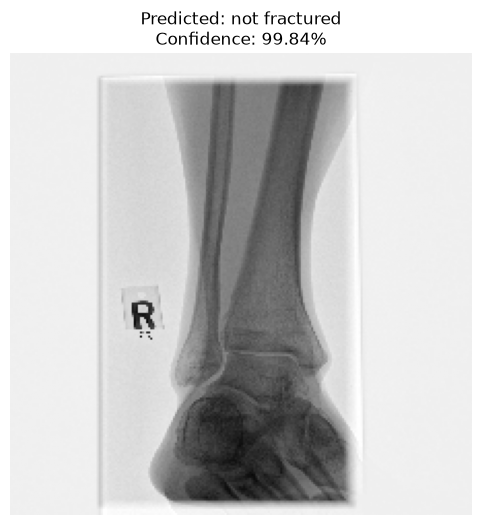

Image: not fractured/4.png
Prediction: not fractured
Confidence: 99.84%


In [64]:
from tensorflow.keras.utils import load_img, img_to_array
image_name = "not fractured/4.png"

image_path = os.path.join(test_path, image_name)

img = load_img(image_path, target_size=(224, 224), color_mode="grayscale")
img_array = img_to_array(img) / 255.0
input_image = np.expand_dims(img_array, axis=0)

prediction = model.predict(input_image, verbose=0)[0][0]

if prediction >= 0.5:
    predicted_class = "not fractured"
    confidence = prediction
else:
    predicted_class = "fractured"
    confidence = 1 - prediction

plt.figure(figsize=(6, 6))
plt.imshow(img_array.squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence * 100:.2f}%")
plt.show()

print("Image:", image_name)
print("Prediction:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

In [62]:
print(test_set.class_indices)
print(test_set.image_shape)
print(test_set.class_mode)
print("Raw prediction:", prediction)
print("Actual:", class_name)

{'fractured': 0, 'not fractured': 1}
(224, 224, 1)
binary
Raw prediction: 0.72758406
Actual: not fractured
